# Classification with a Neural Network — Minimizing the Log Loss (Backpropagation)

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture that derives the gradients to
**train** a neural network (Week 3 — Optimization in Neural Networks and Newton's Method).

This is **backpropagation**: a long chain rule through the layers, with the same neat
cancellation we saw for the perceptron.

This notebook explains:

- the goal — derivatives of the log loss with respect to **every** weight and bias
- the huge chain rule for a hidden weight $w_{11}$ and the bias $b_1$
- all first-layer gradients and the simpler second-layer gradients
- the gradient-descent update rules
- a numeric gradient check and a full training run that learns **XOR** from scratch

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Classification with a Neural Network*.

## 1. The goal

To train the network with gradient descent we need to know how **each** weight and bias
affects the loss — i.e. $\dfrac{\partial L}{\partial w_{ij}}$ and
$\dfrac{\partial L}{\partial b_i}$ for the hidden layer, and
$\dfrac{\partial L}{\partial w_1}, \dfrac{\partial L}{\partial w_2}, \dfrac{\partial L}{\partial b}$
for the output layer.

Recall the forward pass:

$$
z_1 = x_1 w_{11} + x_2 w_{21} + b_1,\quad a_1 = \sigma(z_1),
$$
$$
z_2 = x_1 w_{12} + x_2 w_{22} + b_2,\quad a_2 = \sigma(z_2),
$$
$$
z = a_1 w_1 + a_2 w_2 + b,\quad \hat{y} = \sigma(z),\quad
L = -y\log\hat{y} - (1-y)\log(1-\hat{y}).
$$

## 2. The huge chain rule for a hidden weight $w_{11}$

There are many variables between $L$ and $w_{11}$: $L \leftarrow \hat{y} \leftarrow z
\leftarrow a_1 \leftarrow z_1 \leftarrow w_{11}$. So:

$$
\frac{\partial L}{\partial w_{11}}
= \frac{\partial z_1}{\partial w_{11}}\cdot
  \frac{\partial a_1}{\partial z_1}\cdot
  \frac{\partial z}{\partial a_1}\cdot
  \frac{\partial \hat{y}}{\partial z}\cdot
  \frac{\partial L}{\partial \hat{y}}.
$$

Each factor is easy:

| factor | value |
|---|---|
| $\partial z_1/\partial w_{11}$ | $x_1$ |
| $\partial a_1/\partial z_1$ | $a_1(1-a_1)$ |
| $\partial z/\partial a_1$ | $w_1$ |
| $\partial \hat{y}/\partial z$ | $\hat{y}(1-\hat{y})$ |
| $\partial L/\partial \hat{y}$ | $-\dfrac{y-\hat{y}}{\hat{y}(1-\hat{y})}$ |

Multiplying, the $\hat{y}(1-\hat{y})$ **cancels**:

$$
\boxed{\;\frac{\partial L}{\partial w_{11}} = -(y - \hat{y})\,w_1\,a_1(1-a_1)\,x_1.\;}
$$

## 3. The bias $b_1$ and all first-layer gradients

The only change for $b_1$ is $\partial z_1/\partial b_1 = 1$ instead of $x_1$:

$$
\frac{\partial L}{\partial b_1} = -(y-\hat{y})\,w_1\,a_1(1-a_1).
$$

By the same pattern (the green node uses $a_2$ and $w_2$):

$$
\frac{\partial L}{\partial w_{11}} = -(y-\hat{y})\,w_1\,a_1(1-a_1)\,x_1, \qquad
\frac{\partial L}{\partial w_{21}} = -(y-\hat{y})\,w_1\,a_1(1-a_1)\,x_2,
$$
$$
\frac{\partial L}{\partial w_{12}} = -(y-\hat{y})\,w_2\,a_2(1-a_2)\,x_1, \qquad
\frac{\partial L}{\partial w_{22}} = -(y-\hat{y})\,w_2\,a_2(1-a_2)\,x_2,
$$
$$
\frac{\partial L}{\partial b_1} = -(y-\hat{y})\,w_1\,a_1(1-a_1), \qquad
\frac{\partial L}{\partial b_2} = -(y-\hat{y})\,w_2\,a_2(1-a_2).
$$

## 4. The second (output) layer — much simpler

Fewer variables sit between $L$ and the output weights: $L \leftarrow \hat{y} \leftarrow z
\leftarrow w_1$. So

$$
\frac{\partial L}{\partial w_1}
= \frac{\partial z}{\partial w_1}\cdot\frac{\partial \hat{y}}{\partial z}\cdot\frac{\partial L}{\partial \hat{y}}
= a_1\cdot \hat{y}(1-\hat{y})\cdot\left(-\frac{y-\hat{y}}{\hat{y}(1-\hat{y})}\right)
= -(y-\hat{y})\,a_1 .
$$

So, identically in form to the single perceptron:

$$
\frac{\partial L}{\partial w_1} = -(y-\hat{y})\,a_1, \qquad
\frac{\partial L}{\partial w_2} = -(y-\hat{y})\,a_2, \qquad
\frac{\partial L}{\partial b} = -(y-\hat{y}).
$$

## 5. The update rules

Gradient descent subtracts $\alpha$ times each gradient; the double negative becomes a
plus. Output layer:

$$
w_1 \leftarrow w_1 + \alpha\,(y-\hat{y})\,a_1, \quad
w_2 \leftarrow w_2 + \alpha\,(y-\hat{y})\,a_2, \quad
b \leftarrow b + \alpha\,(y-\hat{y}).
$$

Hidden layer (example):

$$
w_{11} \leftarrow w_{11} + \alpha\,(y-\hat{y})\,w_1\,a_1(1-a_1)\,x_1, \quad
b_1 \leftarrow b_1 + \alpha\,(y-\hat{y})\,w_1\,a_1(1-a_1),
$$

and analogously for the rest.

## 6. Implementation: forward and backward passes

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward(X, P):
    x1, x2 = X[:, 0], X[:, 1]
    a1 = sigmoid(x1*P['w11'] + x2*P['w21'] + P['b1'])
    a2 = sigmoid(x1*P['w12'] + x2*P['w22'] + P['b2'])
    y_hat = sigmoid(a1*P['w1'] + a2*P['w2'] + P['b'])
    return y_hat, a1, a2

def gradients(X, Y, P):
    x1, x2 = X[:, 0], X[:, 1]
    y_hat, a1, a2 = forward(X, P)
    e = Y - y_hat                                  # (y - y_hat)
    g = {}
    # output layer:  ∂L/∂w_i = -(y-ŷ) a_i
    g['w1'] = -np.mean(e * a1); g['w2'] = -np.mean(e * a2); g['b'] = -np.mean(e)
    # hidden layer:  shared factor per node
    c1 = -e * P['w1'] * a1*(1-a1)
    c2 = -e * P['w2'] * a2*(1-a2)
    g['w11'] = np.mean(c1*x1); g['w21'] = np.mean(c1*x2); g['b1'] = np.mean(c1)
    g['w12'] = np.mean(c2*x1); g['w22'] = np.mean(c2*x2); g['b2'] = np.mean(c2)
    return g

def log_loss(Y, y_hat, eps=1e-12):
    y_hat = np.clip(y_hat, eps, 1-eps)
    return np.mean(-Y*np.log(y_hat) - (1-Y)*np.log(1-y_hat))

## 7. Numeric gradient check

We confirm the backprop gradients match a finite-difference estimate of the loss.

In [2]:
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
Y = np.array([0, 1, 1, 0], dtype=float)   # XOR

rng = np.random.default_rng(1)
P = {k: rng.normal() for k in ['w11','w21','b1','w12','w22','b2','w1','w2','b']}

analytic = gradients(X, Y, P)

# finite-difference check
h = 1e-6
print(f"{'param':>5} | {'analytic':>12} | {'numeric':>12}")
for k in P:
    Pp = dict(P); Pm = dict(P)
    Pp[k] += h; Pm[k] -= h
    num = (log_loss(Y, forward(X, Pp)[0]) - log_loss(Y, forward(X, Pm)[0])) / (2*h)
    print(f"{k:>5} | {analytic[k]:>12.6f} | {num:>12.6f}")

param |     analytic |      numeric
  w11 |     0.002499 |     0.002499
  w21 |    -0.001418 |    -0.001418
   b1 |    -0.007382 |    -0.007382
  w12 |     0.006349 |     0.006349
  w22 |     0.010749 |     0.010749
   b2 |     0.017681 |     0.017681
   w1 |     0.050078 |     0.050078
   w2 |     0.049933 |     0.049933
    b |     0.076061 |     0.076061


## 8. Training the network on XOR

Now we run gradient descent with these gradients, starting from random weights. Because a
2-2-1 network can land in poor local minima, we use a few random restarts and keep the best
— echoing the lesson from gradient descent in Week 2.

In [3]:
def train(X, Y, alpha=3.0, epochs=8000, seed=0):
    rng = np.random.default_rng(seed)
    P = {k: rng.normal() for k in ['w11','w21','b1','w12','w22','b2','w1','w2','b']}
    losses = []
    for _ in range(epochs):
        g = gradients(X, Y, P)
        for k in P:
            P[k] -= alpha * g[k]
        losses.append(log_loss(Y, forward(X, P)[0]))
    return P, losses

# random restarts -> keep the best
best = None
for seed in range(10):
    P, losses = train(X, Y, alpha=3.0, epochs=8000, seed=seed)
    if best is None or losses[-1] < best[1][-1]:
        best = (P, losses)
P, losses = best

print(f"final log loss: {losses[-1]:.5f}")
preds = forward(X, P)[0]
for (x1, x2), p, t in zip(X, preds, Y):
    print(f"  ({x1:.0f},{x2:.0f}): ŷ={p:.3f} -> {int(p>=0.5)}  (target {t:.0f})")

final log loss: 0.00039
  (0,0): ŷ=0.000 -> 0  (target 0)
  (0,1): ŷ=0.999 -> 1  (target 1)
  (1,0): ŷ=1.000 -> 1  (target 1)
  (1,1): ŷ=0.000 -> 0  (target 0)


### Loss curve and learned decision boundary

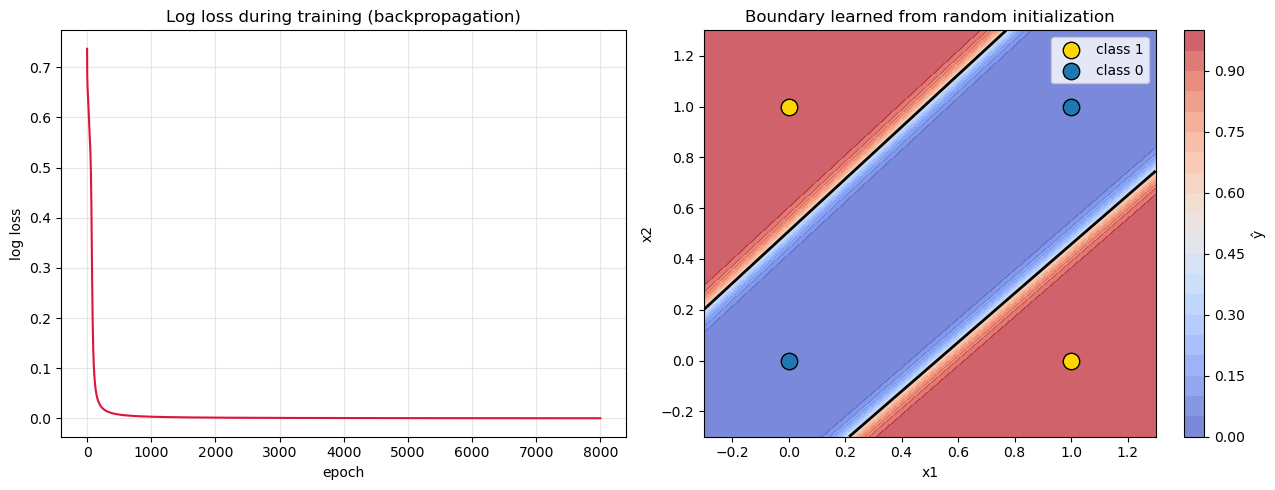

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(losses, color="crimson")
axes[0].set_title("Log loss during training (backpropagation)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("log loss")
axes[0].grid(True, alpha=0.3)

gx = np.linspace(-0.3, 1.3, 200); gy = np.linspace(-0.3, 1.3, 200)
GX, GY = np.meshgrid(gx, gy)
grid = np.column_stack([GX.ravel(), GY.ravel()])
GZ = forward(grid, P)[0].reshape(GX.shape)
cf = axes[1].contourf(GX, GY, GZ, levels=20, cmap="coolwarm", alpha=0.7)
plt.colorbar(cf, ax=axes[1], label="ŷ")
axes[1].contour(GX, GY, GZ, levels=[0.5], colors="black", linewidths=2)
ones = X[Y==1]; zeros = X[Y==0]
axes[1].scatter(ones[:,0], ones[:,1], s=140, color="gold", edgecolor="black", label="class 1")
axes[1].scatter(zeros[:,0], zeros[:,1], s=140, color="tab:blue", edgecolor="black", label="class 0")
axes[1].set_title("Boundary learned from random initialization")
axes[1].set_xlabel("x1"); axes[1].set_ylabel("x2"); axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Exercises

### Basic
1. Write the chain rule for $\partial L/\partial w_{11}$ (list the factors).
2. What is the output-layer gradient $\partial L/\partial w_1$?

### Intermediate
3. Why does the hidden-layer gradient include the factor $w_1$ (the output weight)?
4. Write the update rule for $b_1$.

### Advanced
5. Run the numeric gradient check for a different random seed and confirm the backprop
   gradients still match.
6. Train the network from a single fixed seed (no restarts). Does it always solve XOR?
   Explain in terms of local minima.

## 10. Solutions / Checks

In [5]:
# 5. gradient check for another seed
rng = np.random.default_rng(7)
P2 = {k: rng.normal() for k in ['w11','w21','b1','w12','w22','b2','w1','w2','b']}
g2 = gradients(X, Y, P2)
maxerr = 0.0
for k in P2:
    Pp = dict(P2); Pm = dict(P2); Pp[k]+=1e-6; Pm[k]-=1e-6
    num = (log_loss(Y, forward(X, Pp)[0]) - log_loss(Y, forward(X, Pm)[0]))/(2e-6)
    maxerr = max(maxerr, abs(num - g2[k]))
print(f"5. max |analytic - numeric| = {maxerr:.2e} (≈0 confirms backprop)")

# 6. single-seed runs
solved = 0
for s in range(10):
    _, ls = train(X, Y, alpha=3.0, epochs=8000, seed=s)
    if ls[-1] < 0.05:
        solved += 1
print(f"6. {solved}/10 single-seed runs solved XOR (loss<0.05) -> some get stuck in local minima")

print("1. ∂L/∂w11 = (∂z1/∂w11)(∂a1/∂z1)(∂z/∂a1)(∂ŷ/∂z)(∂L/∂ŷ)")
print("2. ∂L/∂w1 = -(y - ŷ) a1")
print("3. w11 affects L only through the output neuron, whose sensitivity to a1 is w1.")
print("4. b1 <- b1 + α (y - ŷ) w1 a1 (1 - a1)")

5. max |analytic - numeric| = 6.76e-11 (≈0 confirms backprop)


6. 8/10 single-seed runs solved XOR (loss<0.05) -> some get stuck in local minima
1. ∂L/∂w11 = (∂z1/∂w11)(∂a1/∂z1)(∂z/∂a1)(∂ŷ/∂z)(∂L/∂ŷ)
2. ∂L/∂w1 = -(y - ŷ) a1
3. w11 affects L only through the output neuron, whose sensitivity to a1 is w1.
4. b1 <- b1 + α (y - ŷ) w1 a1 (1 - a1)


## 11. Conclusion

- Training a neural network needs the loss gradient for **every** weight and bias, obtained
  by a layered **chain rule** — this is **backpropagation**.
- The output-layer gradients are $-(y-\hat{y})a_i$ and $-(y-\hat{y})$; the hidden-layer
  gradients add the factor $w_j\,a_j(1-a_j)$ (and the input $x_i$ for weights), the error
  "propagating backward" through the output weight and the sigmoid derivative.
- The $\hat{y}(1-\hat{y})$ terms cancel, leaving clean expressions driven by the error
  $(y-\hat{y})$.
- Plugging them into gradient descent trains the network — it learns XOR, a nonlinear
  boundary, from random initialization. Multiple restarts help avoid local minima.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/opt_nns_09.mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 3) lecture on **minimizing the log loss / backpropagation**. Key spoken
points, lightly cleaned:

> To do gradient descent we need how each weight/bias affects the loss, i.e.
> $\partial L/\partial w_{ij}$ and $\partial L/\partial b_i$. For the hidden weight
> $w_{11}$ there are many variables between $L$ and $w_{11}$, giving a long chain rule:
> $\partial L/\partial w_{11} = (\partial z_1/\partial w_{11})(\partial a_1/\partial
> z_1)(\partial z/\partial a_1)(\partial\hat{y}/\partial z)(\partial L/\partial\hat{y})$.
> The factors are $x_1$, $a_1(1-a_1)$, $w_1$, $\hat{y}(1-\hat{y})$, and
> $-(y-\hat{y})/(\hat{y}(1-\hat{y}))$; the $\hat{y}(1-\hat{y})$ cancels, leaving
> $-(y-\hat{y})w_1 a_1(1-a_1)x_1$. The bias $b_1$ is the same but with the first factor $1$.
> The output layer is shorter: $\partial L/\partial w_1 = a_1\cdot\hat{y}(1-\hat{y})\cdot
> (\partial L/\partial\hat{y}) = -(y-\hat{y})a_1$, and similarly $-(y-\hat{y})a_2$ and
> $-(y-\hat{y})$ for $b$. Update every weight and bias with learning rate $\alpha$, and the
> network's weights improve — that's how you train a neural network.